In [31]:
# 1) Connect Google Drive

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
!pip install -q sentence-transformers scikit-learn imbalanced-learn joblib matplotlib

In [33]:
import pandas as pd
import numpy as np
import re
from collections import Counter

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

import joblib

In [34]:

CSV_PATH = "/content/drive/MyDrive/interview_questions_master.csv"
df = pd.read_csv(CSV_PATH)

print("Loaded:", CSV_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head(10))

Loaded: /content/drive/MyDrive/interview_questions_master.csv
Shape: (750, 6)
Columns: ['role', 'question_id', 'question', 'answer_text', 'label', 'score']


,role,question_id,question,answer_text,label,score
0,Business Development Executive,BUS-01,Explain your core responsibilities in this role.,"As a Business Development Executive, I clearly...",Good,9
1,Business Development Executive,BUS-01,Explain your core responsibilities in this role.,"In this Business Development Executive role, I...",Average,6
2,Business Development Executive,BUS-01,Explain your core responsibilities in this role.,I just do whatever is assigned without a clear...,Poor,2
3,Business Development Executive,BUS-02,How do you prioritize tasks under tight deadli...,"As a Business Development Executive, I clearly...",Good,9
4,Business Development Executive,BUS-02,How do you prioritize tasks under tight deadli...,"In this Business Development Executive role, I...",Average,6
5,Business Development Executive,BUS-02,How do you prioritize tasks under tight deadli...,I just do whatever is assigned without a clear...,Poor,2
6,Business Development Executive,BUS-03,Describe a challenging situation you handled s...,"As a Business Development Executive, I clearly...",Good,9
7,Business Development Executive,BUS-03,Describe a challenging situation you handled s...,"In this Business Development Executive role, I...",Average,6
8,Business Development Executive,BUS-03,Describe a challenging situation you handled s...,I just do whatever is assigned without a clear...,Poor,2
9,Business Development Executive,BUS-04,How do you ensure accuracy and quality in your...,"As a Business Development Executive, I clearly...",Good,9


In [35]:
# ===== Stage 1b: Validate columns =====
required_cols = ["role", "question_id", "question", "answer_text", "label"]
missing_cols = [c for c in required_cols if c not in df.columns]
assert len(missing_cols) == 0, f"Missing required columns: {missing_cols}"

print(" Required columns exist.")

 Required columns exist.


In [36]:
# ===== Stage 1c: Missing & duplicates =====
print("\nMissing values per column:\n", df.isna().sum())
print("\nExact duplicate rows:", df.duplicated().sum())
print("Duplicate by (role, question_id, answer_text):",
      df.duplicated(subset=["role","question_id","answer_text"]).sum())

print("\nUnique labels:", df["label"].unique())
print("\nLabel counts:\n", df["label"].value_counts())


Missing values per column:
 role           0
question_id    0
question       0
answer_text    0
label          0
score          0
dtype: int64

Exact duplicate rows: 0
Duplicate by (role, question_id, answer_text): 0

Unique labels: ['Good' 'Average' 'Poor']

Label counts:
 label
Good       250
Average    250
Poor       250
Name: count, dtype: int64


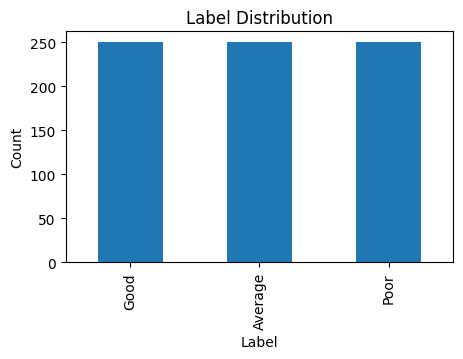

In [37]:
# ===== Stage 2: EDA =====
plt.figure(figsize=(5,3))
df["label"].value_counts().plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


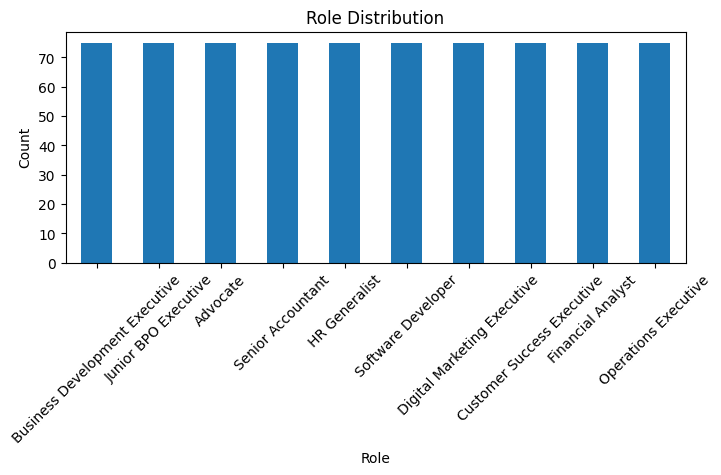

In [38]:
plt.figure(figsize=(8,3))
df["role"].value_counts().plot(kind="bar")
plt.title("Role Distribution")
plt.xlabel("Role")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [39]:
role_label = pd.crosstab(df["role"], df["label"])
display(role_label)

role_label_norm = role_label.div(role_label.sum(axis=1), axis=0)
display(role_label_norm)

label,Average,Good,Poor
role,,,
Advocate,25,25,25
Business Development Executive,25,25,25
Customer Success Executive,25,25,25
Digital Marketing Executive,25,25,25
Financial Analyst,25,25,25
HR Generalist,25,25,25
Junior BPO Executive,25,25,25
Operations Executive,25,25,25
Senior Accountant,25,25,25


label,Average,Good,Poor
role,,,
Advocate,0.333333,0.333333,0.333333
Business Development Executive,0.333333,0.333333,0.333333
Customer Success Executive,0.333333,0.333333,0.333333
Digital Marketing Executive,0.333333,0.333333,0.333333
Financial Analyst,0.333333,0.333333,0.333333
HR Generalist,0.333333,0.333333,0.333333
Junior BPO Executive,0.333333,0.333333,0.333333
Operations Executive,0.333333,0.333333,0.333333
Senior Accountant,0.333333,0.333333,0.333333


In [48]:
import re

def clean_text(x):
    x = str(x).lower()
    x = re.sub(r"\s+", " ", x).strip()   # normalize spaces
    return x

df["answer_clean"] = df["answer_text"].apply(clean_text)

# --- Word count ---
df["word_count"] = df["answer_clean"].apply(lambda x: len(x.split()))

# --- Describe by label ---
display(df.groupby("label")["word_count"].describe())

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Average,250.0,17.3,0.641597,16.0,17.0,17.0,18.0,18.0
Good,250.0,22.3,0.641597,21.0,22.0,22.0,23.0,23.0
Poor,250.0,13.0,0.000000,13.0,13.0,13.0,13.0,13.0


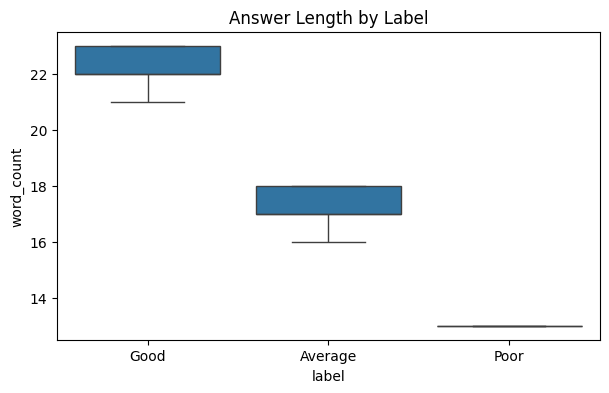

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="label", y="word_count")
plt.title("Answer Length by Label")
plt.show()

count    750.000000
mean      17.533333
std        3.838646
min       13.000000
25%       13.000000
50%       17.000000
75%       22.000000
max       23.000000
Name: answer_word_count, dtype: float64


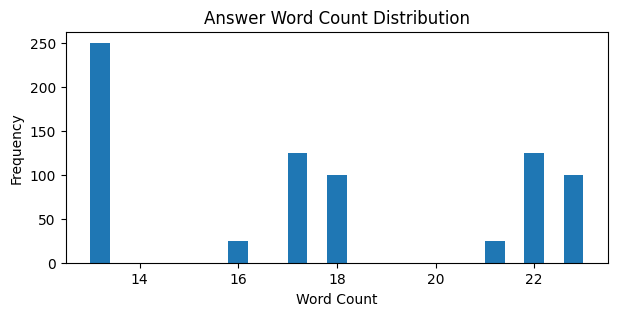

,role,label,answer_word_count,answer_text
728,Operations Executive,Poor,13,I just do whatever is assigned without a clear...
725,Operations Executive,Poor,13,I just do whatever is assigned without a clear...
17,Business Development Executive,Poor,13,I just do whatever is assigned without a clear...
716,Operations Executive,Poor,13,I just do whatever is assigned without a clear...
713,Operations Executive,Poor,13,I just do whatever is assigned without a clear...
710,Operations Executive,Poor,13,I just do whatever is assigned without a clear...
35,Business Development Executive,Poor,13,I just do whatever is assigned without a clear...
32,Business Development Executive,Poor,13,I just do whatever is assigned without a clear...
29,Business Development Executive,Poor,13,I just do whatever is assigned without a clear...
26,Business Development Executive,Poor,13,I just do whatever is assigned without a clear...


In [50]:
def word_count(text):
    return len(str(text).split())

df["answer_word_count"] = df["answer_text"].apply(word_count)
print(df["answer_word_count"].describe())

plt.figure(figsize=(7,3))
df["answer_word_count"].plot(kind="hist", bins=25)
plt.title("Answer Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

display(df.sort_values("answer_word_count").head(10)[
    ["role","label","answer_word_count","answer_text"]
])

In [51]:
# ===== Stage 3: Cleaning =====
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    text = re.sub(r"[\r\n\t]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text

df["answer_clean"] = df["answer_text"].apply(clean_text)
df["question_clean"] = df["question"].apply(clean_text)

# Question-aware combined text (important academically)
df["qa_text"] = "Q: " + df["question_clean"] + " A: " + df["answer_clean"]

display(df[["question_clean","answer_clean","qa_text","label"]].head(5))

,question_clean,answer_clean,qa_text,label
0,Explain your core responsibilities in this role.,"As a Business Development Executive, I clearly...",Q: Explain your core responsibilities in this ...,Good
1,Explain your core responsibilities in this role.,"In this Business Development Executive role, I...",Q: Explain your core responsibilities in this ...,Average
2,Explain your core responsibilities in this role.,I just do whatever is assigned without a clear...,Q: Explain your core responsibilities in this ...,Poor
3,How do you prioritize tasks under tight deadli...,"As a Business Development Executive, I clearly...",Q: How do you prioritize tasks under tight dea...,Good
4,How do you prioritize tasks under tight deadli...,"In this Business Development Executive role, I...",Q: How do you prioritize tasks under tight dea...,Average


In [52]:
# ===== Stage 3b: Sanity checks =====
print("Empty answers:", (df["answer_clean"].str.len() == 0).sum())
print("Very short answers (<5 words):", (df["answer_word_count"] < 5).sum())

print("\nUnique roles:", df["role"].nunique(), sorted(df["role"].unique())[:10])
print("Unique question_id:", df["question_id"].nunique())

Empty answers: 0
Very short answers (<5 words): 0

Unique roles: 10 ['Advocate', 'Business Development Executive', 'Customer Success Executive', 'Digital Marketing Executive', 'Financial Analyst', 'HR Generalist', 'Junior BPO Executive', 'Operations Executive', 'Senior Accountant', 'Software Developer']
Unique question_id: 250


In [53]:
# ===== Stage 4.1: Label Encoding =====
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label"])

print("Classes (order matters):", list(le.classes_))
display(df[["label","label_encoded"]].drop_duplicates().sort_values("label_encoded"))

Classes (order matters): ['Average', 'Good', 'Poor']


,label,label_encoded
1,Average,0
0,Good,1
2,Poor,2


In [54]:
# ===== Stage 4.2: Leakage-safe split by question_id =====
import numpy as np

RANDOM_SEED = 42
TEST_QUESTION_FRAC = 0.20   # with 10 question_ids, this holds out ~2

unique_qids = df["question_id"].dropna().unique()
rng = np.random.default_rng(RANDOM_SEED)

n_test = max(1, int(round(len(unique_qids) * TEST_QUESTION_FRAC)))
test_qids = rng.choice(unique_qids, size=n_test, replace=False)

train_df = df[~df["question_id"].isin(test_qids)].copy()
test_df  = df[df["question_id"].isin(test_qids)].copy()

print("Total rows:", len(df))
print("Train rows:", len(train_df), " Test rows:", len(test_df))
print("Held-out question_ids:", sorted(list(test_qids))[:20], "..." if len(test_qids)>20 else "")
print("Train unique qids:", train_df["question_id"].nunique(), " Test unique qids:", test_df["question_id"].nunique())

print("\nTrain label counts:\n", train_df["label"].value_counts())
print("\nTest label counts:\n", test_df["label"].value_counts())

Total rows: 750
Train rows: 600  Test rows: 150
Held-out question_ids: ['15-Jun', '16-Jun', '18-Jun', '3-Jun', 'ADV-03', 'ADV-17', 'BUS-16', 'BUS-17', 'BUS-18', 'BUS-20', 'BUS-22', 'CUS-01', 'CUS-02', 'CUS-09', 'CUS-13', 'CUS-20', 'CUS-22', 'DIG-02', 'DIG-05', 'DIG-07'] ...
Train unique qids: 200  Test unique qids: 50

Train label counts:
 label
Good       200
Average    200
Poor       200
Name: count, dtype: int64

Test label counts:
 label
Good       50
Average    50
Poor       50
Name: count, dtype: int64


In [55]:
# ===== Stage 4.3: Build X/y =====
X_train_text = train_df["qa_text"].values
y_train = train_df["label_encoded"].values

X_test_text = test_df["qa_text"].values
y_test = test_df["label_encoded"].values

print("X_train:", X_train_text.shape, "y_train:", y_train.shape)
print("X_test :", X_test_text.shape, "y_test :", y_test.shape)

X_train: (600,) y_train: (600,)
X_test : (150,) y_test : (150,)


In [56]:
# ===== Stage 4.4: Dummy baseline =====
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)

dummy.fit(np.zeros((len(X_train_text), 1)), y_train)
y_pred_dummy = dummy.predict(np.zeros((len(X_test_text), 1)))

print("Dummy Accuracy:", round(accuracy_score(y_test, y_pred_dummy), 4))
print("Dummy Macro-F1:", round(f1_score(y_test, y_pred_dummy, average="macro"), 4))

Dummy Accuracy: 0.3333
Dummy Macro-F1: 0.1667


In [57]:
# ===== Stage 4.5: TF-IDF + Logistic Regression baseline =====
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf_lr = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2)),
    ("clf", LogisticRegression(max_iter=3000, random_state=RANDOM_SEED))
])

tfidf_lr.fit(X_train_text, y_train)
y_pred_tfidf = tfidf_lr.predict(X_test_text)

print("TF-IDF+LR Accuracy:", round(accuracy_score(y_test, y_pred_tfidf), 4))
print("TF-IDF+LR Macro-F1:", round(f1_score(y_test, y_pred_tfidf, average="macro"), 4))

TF-IDF+LR Accuracy: 1.0
TF-IDF+LR Macro-F1: 1.0



Confusion Matrix — Dummy (Most Frequent)
Accuracy: 0.3333
Macro-F1: 0.1667

Classification Report:

              precision    recall  f1-score   support

     Average       0.33      1.00      0.50        50
        Good       0.00      0.00      0.00        50
        Poor       0.00      0.00      0.00        50

    accuracy                           0.33       150
   macro avg       0.11      0.33      0.17       150
weighted avg       0.11      0.33      0.17       150



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


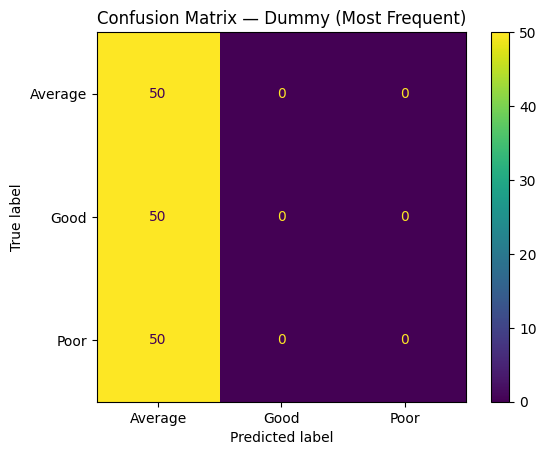


Confusion Matrix — TF-IDF + Logistic Regression
Accuracy: 1.0
Macro-F1: 1.0

Classification Report:

              precision    recall  f1-score   support

     Average       1.00      1.00      1.00        50
        Good       1.00      1.00      1.00        50
        Poor       1.00      1.00      1.00        50

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



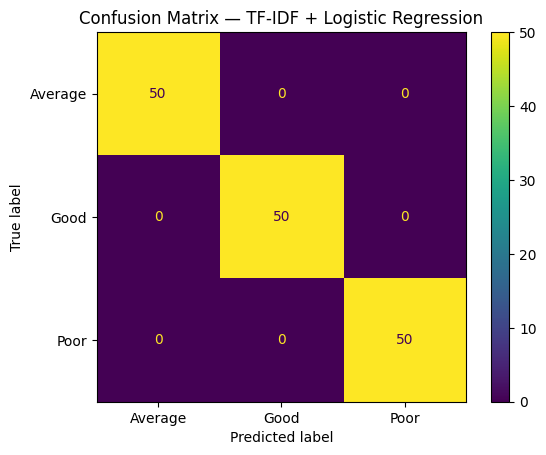

In [58]:
# ===== Stage 4.6: Reporting helper =====
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def show_report(y_true, y_pred, title):
    print("\n" + "="*60)
    print(title)
    print("="*60)
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print("Macro-F1:", round(f1_score(y_true, y_pred, average="macro"), 4))
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(values_format="d")
    plt.title(title)
    plt.show()

show_report(y_test, y_pred_dummy, "Confusion Matrix — Dummy (Most Frequent)")
show_report(y_test, y_pred_tfidf, "Confusion Matrix — TF-IDF + Logistic Regression")

In [59]:
# ===== Stage 5.0: Imports + sanity =====
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Make sure these exist from earlier stages
assert "qa_text" in df.columns, "qa_text not found. Run Stage 3 first."
assert "question_clean" in df.columns, "question_clean not found. Run Stage 3 first."
assert "label_encoded" in df.columns, "label_encoded not found. Run Stage 4.1 first."
assert "RANDOM_SEED" in globals(), "RANDOM_SEED not defined. Set it (e.g., 42)."

print("✅ Stage 5.0 ready")

✅ Stage 5.0 ready


In [60]:
# ===== Stage 5.1: SBERT embeddings (QA-aware) for Train/Test =====
SBERT_MODEL = "bert-base-nli-mean-tokens"
sbert = SentenceTransformer(SBERT_MODEL)
print("Loaded SBERT:", SBERT_MODEL)

# These must exist from Stage 4 split
assert "X_train_text" in globals() and "X_test_text" in globals(), "Run Stage 4 split first."

X_train_emb = sbert.encode(
    list(X_train_text),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

X_test_emb = sbert.encode(
    list(X_test_text),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Train emb shape:", X_train_emb.shape)
print("Test  emb shape:", X_test_emb.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded SBERT: bert-base-nli-mean-tokens


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Train emb shape: (600, 768)
Test  emb shape: (150, 768)


In [61]:
# ===== Stage 5.2: Train/Test evaluation (SBERT(QA)+RF and SBERT(QA)+LR) =====
rf_tt = RandomForestClassifier(
    n_estimators=600, max_depth=None, min_samples_leaf=1,
    class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1
)

lr_tt = LogisticRegression(
    max_iter=4000, class_weight="balanced", random_state=RANDOM_SEED
)

rf_tt.fit(X_train_emb, y_train)
lr_tt.fit(X_train_emb, y_train)

pred_rf = rf_tt.predict(X_test_emb)
pred_lr = lr_tt.predict(X_test_emb)

print("SBERT(QA)+RF  | Acc:", round(accuracy_score(y_test, pred_rf), 4),
      "| Macro-F1:", round(f1_score(y_test, pred_rf, average="macro"), 4))

print("SBERT(QA)+LR  | Acc:", round(accuracy_score(y_test, pred_lr), 4),
      "| Macro-F1:", round(f1_score(y_test, pred_lr, average="macro"), 4))

SBERT(QA)+RF  | Acc: 1.0 | Macro-F1: 1.0
SBERT(QA)+LR  | Acc: 1.0 | Macro-F1: 1.0


In [62]:
# ===== Stage 5.3: Leakage checks + Deduplicate =====

# (A) repeated question text across different question_id
q_dups = df.groupby("question_clean")["question_id"].nunique().sort_values(ascending=False)
print("Questions repeated with multiple question_id:", int((q_dups > 1).sum()))
display(q_dups.head(10))

# (B) duplicates
dup_qa = int(df.duplicated(subset=["qa_text", "label"]).sum())
dup_ans = int(df.duplicated(subset=["answer_clean", "label"]).sum()) if "answer_clean" in df.columns else None
print("Duplicate (qa_text,label):", dup_qa)
print("Duplicate (answer_clean,label):", dup_ans)

# (C) label words inside text
leak_terms = ["good", "average", "poor"]
df["leak_flag"] = df["qa_text"].str.lower().apply(lambda t: any(w in t for w in leak_terms))
print("Rows containing label words in qa_text:", int(df["leak_flag"].sum()))
if int(df["leak_flag"].sum()) > 0:
    display(df[df["leak_flag"]][["qa_text","label"]].head(10))

# (D) Deduplicate (recommended before CV)
print("\nBefore dedup:", df.shape)
df_cv = df.drop_duplicates(subset=["qa_text", "label"]).copy()
print("After dedup :", df_cv.shape)

Questions repeated with multiple question_id: 25


,question_id
question_clean,
Describe a challenging situation you handled successfully.,10
Describe a leadership or initiative experience.,10
Describe a time you improved a process.,10
Describe your approach to customer/client satisfaction.,10
Describe your decision-making process.,10
Describe your problem-solving approach.,10
Explain your core responsibilities in this role.,10
How do you adapt to new systems or tools?,10
How do you analyze data to make decisions?,10


Duplicate (qa_text,label): 225
Duplicate (answer_clean,label): 729
Rows containing label words in qa_text: 0

Before dedup: (750, 13)
After dedup : (525, 13)


Batches:   0%|          | 0/17 [00:00<?, ?it/s]

All embeddings shape: (525, 768)
Unique groups (question_clean): 25
SBERT(QA)+RF | Fold 1/5 | Macro-F1: 1.0000 | Acc: 1.0000
SBERT(QA)+RF | Fold 2/5 | Macro-F1: 1.0000 | Acc: 1.0000
SBERT(QA)+RF | Fold 3/5 | Macro-F1: 1.0000 | Acc: 1.0000
SBERT(QA)+RF | Fold 4/5 | Macro-F1: 1.0000 | Acc: 1.0000
SBERT(QA)+RF | Fold 5/5 | Macro-F1: 1.0000 | Acc: 1.0000

SBERT(QA)+RF CV Summary | Macro-F1 mean: 1.0000 std: 0.0000
SBERT(QA)+RF CV Summary | Acc mean: 1.0000 std: 0.0000

SBERT(QA)+LR | Fold 1/5 | Macro-F1: 1.0000 | Acc: 1.0000
SBERT(QA)+LR | Fold 2/5 | Macro-F1: 1.0000 | Acc: 1.0000
SBERT(QA)+LR | Fold 3/5 | Macro-F1: 1.0000 | Acc: 1.0000
SBERT(QA)+LR | Fold 4/5 | Macro-F1: 1.0000 | Acc: 1.0000
SBERT(QA)+LR | Fold 5/5 | Macro-F1: 1.0000 | Acc: 1.0000

SBERT(QA)+LR CV Summary | Macro-F1 mean: 1.0000 std: 0.0000
SBERT(QA)+LR CV Summary | Acc mean: 1.0000 std: 0.0000



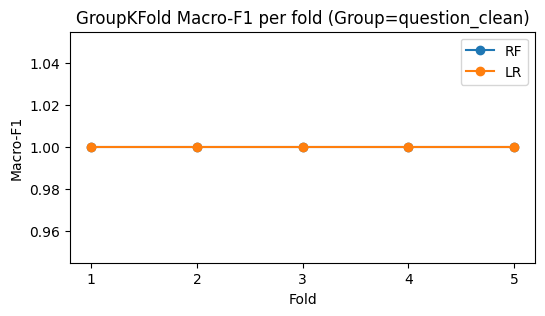

In [63]:
# ===== Stage 5.4: GroupKFold CV grouped by question_clean =====

X_all_text = df_cv["qa_text"].astype(str).values
y_all = df_cv["label_encoded"].values

# ✅ Strong grouping: question_clean (prevents “same question, different id” leakage)
groups = df_cv["question_clean"].values

# Encode SBERT embeddings for full CV set
X_all_emb = sbert.encode(
    list(X_all_text),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("All embeddings shape:", X_all_emb.shape)
print("Unique groups (question_clean):", len(np.unique(groups)))

n_splits = min(5, len(np.unique(groups)))
assert n_splits >= 2, "Need at least 2 unique question_clean groups for GroupKFold."
gkf = GroupKFold(n_splits=n_splits)

def cv_eval(model, X, y, groups, name):
    f1s, accs = [], []
    for fold, (tr, va) in enumerate(gkf.split(X, y, groups), start=1):

        # re-init model each fold
        if isinstance(model, RandomForestClassifier):
            m = RandomForestClassifier(**model.get_params())
        elif isinstance(model, LogisticRegression):
            m = LogisticRegression(**model.get_params())
        else:
            raise ValueError("Model must be RF or LR")

        m.fit(X[tr], y[tr])
        pred = m.predict(X[va])

        fold_f1 = f1_score(y[va], pred, average="macro")
        fold_acc = accuracy_score(y[va], pred)

        f1s.append(fold_f1)
        accs.append(fold_acc)

        print(f"{name} | Fold {fold}/{n_splits} | Macro-F1: {fold_f1:.4f} | Acc: {fold_acc:.4f}")

    print(f"\n{name} CV Summary | Macro-F1 mean: {np.mean(f1s):.4f} std: {np.std(f1s):.4f}")
    print(f"{name} CV Summary | Acc mean: {np.mean(accs):.4f} std: {np.std(accs):.4f}\n")
    return f1s, accs

rf_cv_model = RandomForestClassifier(
    n_estimators=600, max_depth=None, min_samples_leaf=1,
    class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1
)

lr_cv_model = LogisticRegression(
    max_iter=4000, class_weight="balanced", random_state=RANDOM_SEED
)

rf_f1s, rf_accs = cv_eval(rf_cv_model, X_all_emb, y_all, groups, "SBERT(QA)+RF")
lr_f1s, lr_accs = cv_eval(lr_cv_model, X_all_emb, y_all, groups, "SBERT(QA)+LR")

plt.figure(figsize=(6,3))
plt.plot(range(1, n_splits+1), rf_f1s, marker="o", label="RF")
plt.plot(range(1, n_splits+1), lr_f1s, marker="o", label="LR")
plt.title("GroupKFold Macro-F1 per fold (Group=question_clean)")
plt.xlabel("Fold")
plt.ylabel("Macro-F1")
plt.xticks(range(1, n_splits+1))
plt.legend()
plt.show()

In [64]:
from sklearn.model_selection import GroupKFold
groups_role = df_cv["role"].values
n_splits = min(5, len(np.unique(groups_role)))
gkf_role = GroupKFold(n_splits=n_splits)
print("Unique roles:", len(np.unique(groups_role)), "n_splits:", n_splits)

def cv_eval_with_gkf(gkf, model, X, y, groups, name):
    f1s, accs = [], []
    for fold, (tr, va) in enumerate(gkf.split(X, y, groups), start=1):
        m = model.__class__(**model.get_params())
        m.fit(X[tr], y[tr])
        pred = m.predict(X[va])
        f1s.append(f1_score(y[va], pred, average="macro"))
        accs.append(accuracy_score(y[va], pred))
        print(f"{name} | Fold {fold}/{gkf.get_n_splits()} | Macro-F1: {f1s[-1]:.4f} | Acc: {accs[-1]:.4f}")
    print(f"{name} mean Macro-F1: {np.mean(f1s):.4f} std: {np.std(f1s):.4f}")
    return f1s, accs

# Reuse X_all_emb, y_all from your CV cell
rf_model = RandomForestClassifier(n_estimators=600, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
lr_model = LogisticRegression(max_iter=4000, class_weight="balanced", random_state=RANDOM_SEED)

cv_eval_with_gkf(gkf_role, rf_model, X_all_emb, y_all, groups_role, "Role-CV SBERT+RF")
cv_eval_with_gkf(gkf_role, lr_model, X_all_emb, y_all, groups_role, "Role-CV SBERT+LR")

Unique roles: 10 n_splits: 5
Role-CV SBERT+RF | Fold 1/5 | Macro-F1: 0.5978 | Acc: 0.8000
Role-CV SBERT+RF | Fold 2/5 | Macro-F1: 0.9900 | Acc: 0.9900
Role-CV SBERT+RF | Fold 3/5 | Macro-F1: 1.0000 | Acc: 1.0000
Role-CV SBERT+RF | Fold 4/5 | Macro-F1: 1.0000 | Acc: 1.0000
Role-CV SBERT+RF | Fold 5/5 | Macro-F1: 1.0000 | Acc: 1.0000
Role-CV SBERT+RF mean Macro-F1: 0.9176 std: 0.1599
Role-CV SBERT+LR | Fold 1/5 | Macro-F1: 0.6000 | Acc: 0.8000
Role-CV SBERT+LR | Fold 2/5 | Macro-F1: 0.9900 | Acc: 0.9900
Role-CV SBERT+LR | Fold 3/5 | Macro-F1: 1.0000 | Acc: 1.0000
Role-CV SBERT+LR | Fold 4/5 | Macro-F1: 1.0000 | Acc: 1.0000
Role-CV SBERT+LR | Fold 5/5 | Macro-F1: 1.0000 | Acc: 1.0000
Role-CV SBERT+LR mean Macro-F1: 0.9180 std: 0.1590


([0.6, 0.9899989998999901, 1.0, 1.0, 1.0], [0.8, 0.99, 1.0, 1.0, 1.0])

In [65]:
# ===== Stage 5.5: Train final model on ALL data + probability scoring =====

rf_mean = float(np.mean(rf_f1s))
lr_mean = float(np.mean(lr_f1s))
FINAL_MODEL_TYPE = "LR" if lr_mean >= rf_mean else "RF"

print("RF mean Macro-F1:", round(rf_mean, 4))
print("LR mean Macro-F1:", round(lr_mean, 4))
print("✅ Choosing final model:", FINAL_MODEL_TYPE)

if FINAL_MODEL_TYPE == "RF":
    final_model = RandomForestClassifier(
        n_estimators=600, max_depth=None, min_samples_leaf=1,
        class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1
    )
else:
    final_model = LogisticRegression(
        max_iter=4000, class_weight="balanced", random_state=RANDOM_SEED
    )

final_model.fit(X_all_emb, y_all)
print("✅ Final model trained on:", X_all_emb.shape)
print("Label classes:", list(le.classes_))

# Probability-based scoring
score_map = {"Good": 10, "Average": 6, "Poor": 2}

class_names = list(le.classes_)
score_vec = np.array([score_map[c] for c in class_names], dtype=float)

def predict_answer_with_score(question_text: str, answer_text: str):
    q = clean_text(question_text)
    a = clean_text(answer_text)
    qa = f"Q: {q} A: {a}"

    emb = sbert.encode([qa], normalize_embeddings=True)
    proba = final_model.predict_proba(emb)[0]

    pred_id = int(np.argmax(proba))
    pred_label = le.inverse_transform([pred_id])[0]

    expected_score = float(np.dot(proba, score_vec))
    confidence = float(np.max(proba))

    return {
        "pred_label": pred_label,
        "expected_score": round(expected_score, 2),
        "confidence": round(confidence, 3),
        "proba_by_class": {class_names[i]: round(float(proba[i]), 3) for i in range(len(class_names))}
    }

print(predict_answer_with_score(
    "Describe a time you handled conflict in a team.",
    "I listened to both sides, clarified priorities, and agreed on responsibilities. We delivered on time."
))

RF mean Macro-F1: 1.0
LR mean Macro-F1: 1.0
✅ Choosing final model: LR
✅ Final model trained on: (525, 768)
Label classes: ['Average', 'Good', 'Poor']
{'pred_label': 'Average', 'expected_score': 6.58, 'confidence': 0.704, 'proba_by_class': {'Average': 0.704, 'Good': 0.22, 'Poor': 0.075}}


In [66]:
# ===== Stage 5.6: Save artifacts =====
import os, json, joblib

ARTIFACT_DIR = "hirenext_artifacts_v2"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

joblib.dump(final_model, f"{ARTIFACT_DIR}/interview_model.joblib")
joblib.dump(le, f"{ARTIFACT_DIR}/label_encoder.joblib")

with open(f"{ARTIFACT_DIR}/sbert_config.json", "w") as f:
    json.dump({
        "sbert_model": SBERT_MODEL,
        "uses_qa_text": True,
        "grouping": "question_clean",
        "deduplicated": True,
        "embedding_dimension": int(X_all_emb.shape[1])
    }, f, indent=2)

with open(f"{ARTIFACT_DIR}/score_map.json", "w") as f:
    json.dump(score_map, f, indent=2)

print("✅ Saved:", os.listdir(ARTIFACT_DIR))

✅ Saved: ['score_map.json', 'sbert_config.json', 'label_encoder.joblib', 'interview_model.joblib']
